In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#getting to know dataset
df=pd.read_csv('sales.csv')
print(f"the first 5 rows of sales data is: \n{df.head()}\n")
print(f'shape of dataset:{df.shape}\n')
print (f'name of columns:\n{df.columns}')

the first 5 rows of sales data is: 
         Date Product Region  Quantity  Revenue
0  2024-01-05       A  North        10     1000
1  2024-01-10       B  South         5      500
2  2024-01-15       C   East         8      800
3  2024-02-03       A  North        12     1200
4  2024-02-08       B  South         7      700

shape of dataset:(12, 5)

name of columns:
Index(['Date', 'Product', 'Region', 'Quantity', 'Revenue'], dtype='object')


In [ ]:
#general information about dataset
total_revenue=df['Revenue'].sum()
total_quantity=df['Quantity'].sum()
avg_revenue=df['Revenue'].mean()
print(f'Total Revenue:{total_revenue}')
print(f'Total Quantity sold:{total_quantity}')
print(f'Average Revenue per transaction:{round(avg_revenue,2)}')

Total Revenue:12700
Total Quantity sold:127
Average Revenue per transaction:1058.33


In [ ]:
#revenue per product
rev_per_prod=df.groupby('Product')['Revenue'].sum()
print(f"total revenue per product:\n{rev_per_prod}")
avg_rev_per_prod=df.groupby('Product')['Revenue'].mean()
print(f"\nAverage revenue per product: \n{round(avg_rev_per_prod)}")
print (f"best product by revenue: {avg_rev_per_prod.idxmax()} (average revenue of {avg_rev_per_prod.max()})")
print(f'worst product by revenue: {avg_rev_per_prod.idxmin()} (average revenue of {avg_rev_per_prod.min()})')

total revenue per product:
Product
A    5700
B    3100
C    3900
Name: Revenue, dtype: int64

Average revenue per product: 
Product
A    1425.0
B     775.0
C     975.0
Name: Revenue, dtype: float64
best product by revenue: A (average revenue of 1425.0)
worst product by revenue: B (average revenue of 775.0)


In [ ]:
#revenue per region
total_rev_per_region=df.groupby('Region')['Revenue'].sum()
print(f" total revenue per region : {total_rev_per_region}")
print(f"best region for sales is {total_rev_per_region.idxmax()} with total revenue of {total_rev_per_region.max()}")

 total revenue per region : Region
East     3400
North    4500
South    2300
West     2500
Name: Revenue, dtype: int64
best region for sales is North with total revenue of 4500


In [ ]:
#revenue by month
df['Date']=pd.to_datetime(df['Date'])
df["Month"]=df['Date'].dt.month_name()
total_rev_per_month=df.groupby("Month")["Revenue"].sum()
order = ['January','February','March','April','May','June',
         'July','August','September','October','November','December']

total_rev_per_month = total_rev_per_month.reindex(order)
print(f"total revenue per month: \n {total_rev_per_month}")
print(f"best month for sales is {total_rev_per_month.idxmax()} with total revenue {total_rev_per_month.max()}")

total revenue per month: 
 Month
January      2300.0
February     2500.0
March        3500.0
April        4400.0
May             NaN
June            NaN
July            NaN
August          NaN
September       NaN
October         NaN
November        NaN
December        NaN
Name: Revenue, dtype: float64
best month for sales is April with total revenue 4400.0


In [62]:
import matplotlib.pyplot as plt

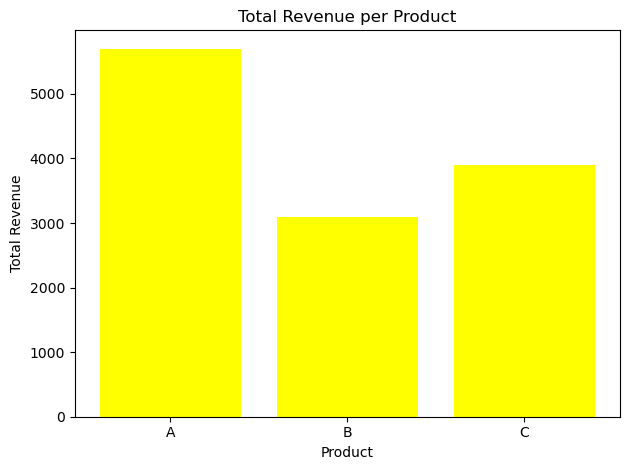

In [83]:
#revenue comparison by product
plt.bar(rev_per_prod.index, rev_per_prod, color='yellow')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.title('Total Revenue per Product')
plt.tight_layout()
plt.show()

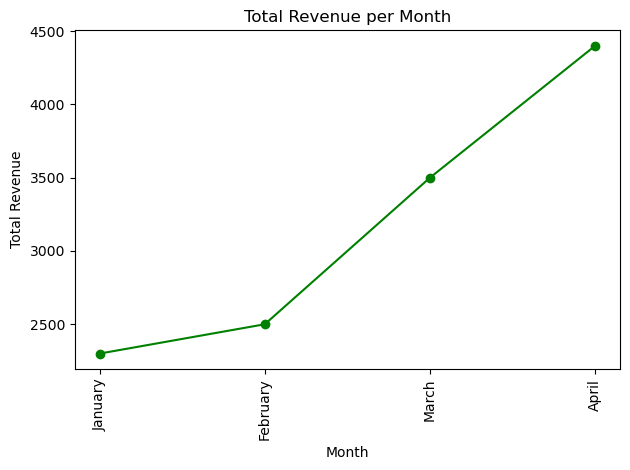

In [84]:
#trend of revenue by month
plt.plot(total_rev_per_month.index, total_rev_per_month, marker='o', color='green')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.title('Total Revenue per Month')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

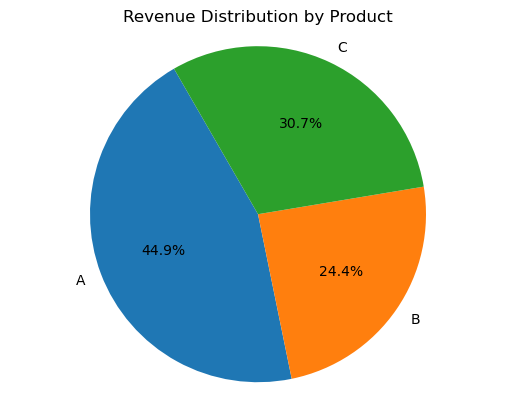

In [ ]:
#revenue distribution by product
plt.pie(rev_per_prod, labels=rev_per_prod.index, autopct='%1.1f%%', startangle=120)   
plt.title('Revenue Distribution by Product')
plt.axis('equal')
plt.show()

The analysis shows that Product A generates the highest revenue, making it the best-performing product. The North region contributes the most to total sales, indicating strong market performance in that area. Monthly sales exhibit an increasing trend, suggesting growing customer demand over time. April is identified as the strongest sales month. Based on these insights, the company should prioritize Product A, strengthen operations in the North region, and plan inventory and marketing strategies according to monthly sales trends.
